1. Train a simple neural network using Keras on the Fashion MNIST dataset and plot both training loss and validation loss for each epoch using matplotlib.


c:\Users\tejal\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8189 - loss: 0.5140 - val_accuracy: 0.8431 - val_loss: 0.4415
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8603 - loss: 0.3896 - val_accuracy: 0.8676 - val_loss: 0.3766
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8746 - loss: 0.3459 - val_accuracy: 0.8691 - val_loss: 0.3611
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8829 - loss: 0.3195 - val_accuracy: 0.8773 - val_loss: 0.3548
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8902 - loss: 0.2990 - val_accuracy: 0.8763 - val_loss: 0.3462
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8949 - loss: 0.2839 - val_accuracy: 0.8851 - val_loss: 0.3193
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8994 - loss: 0.2692 - val_accuracy: 0.8773 - val_loss: 0.3519
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9024 - loss: 0.2608 - 

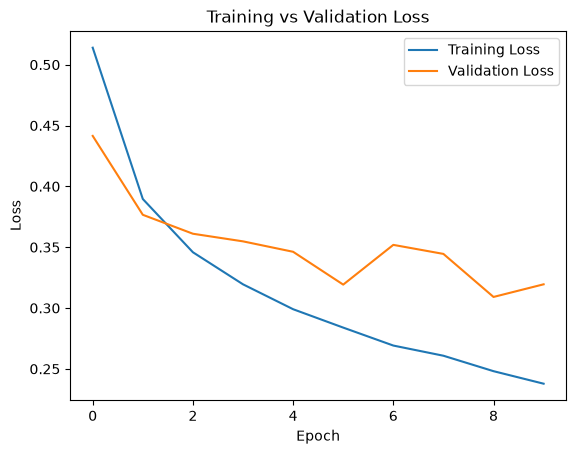

In [1]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize Data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build Model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

# Plot Loss Curves
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

2. Intentionally overfit a small neural network on a subset of the Fashion MNIST data (e.g., only 500 samples) and describe two signs from your loss curves that indicate overfitting.<br><br><em><strong>Hint:</strong> Look for divergence between training and validation loss after a certain number of epochs.</em>

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9475 - loss: 0.1520 - val_accuracy: 0.9400 - val_loss: 0.1872
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9700 - loss: 0.1024 - val_accuracy: 0.9100 - val_loss: 0.1788
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9825 - loss: 0.0754 - val_accuracy: 0.9100 - val_loss: 0.1934
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9900 - loss: 0.0555 - val_accuracy: 0.9000 - val_loss: 0.1740
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9975 - loss: 0.0452 - val_accuracy: 0.9100 - val_loss: 0.1838
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9925 - loss: 0.0422 - val_accuracy: 0.9100 - val_loss: 0.1889
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0391 - val_accuracy: 0.9100 - val_loss: 0.1796
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9975 - loss: 0.0330 - val_accuracy: 0.9100 - val_loss:

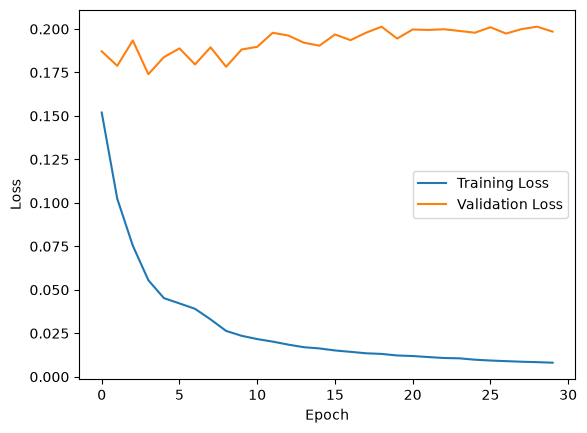

In [6]:
# Use only 500 samples
X_small = X_train[:500]
y_small = y_train[:500]

history = model.fit(
    X_small,
    y_small,
    epochs=30,
    validation_split=0.2
)

# Plot Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

3. Add an EarlyStopping callback to your Keras model training so that it stops if validation loss does not improve for 3 consecutive epochs, and report after how many epochs the training stopped.

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stop]
)

print("Training stopped after", len(history.history['loss']), "epochs")

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9212 - loss: 0.2093 - val_accuracy: 0.8891 - val_loss: 0.3249
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9279 - loss: 0.1954 - val_accuracy: 0.8879 - val_loss: 0.3379
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9301 - loss: 0.1895 - val_accuracy: 0.8872 - val_loss: 0.3440
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9313 - loss: 0.1837 - val_accuracy: 0.8952 - val_loss: 0.3312
Training stopped after 4 epochs


4. After training your Fashion MNIST model, calculate and print the accuracy, precision, and recall for the test set using scikit-learn's metrics functions.

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np

# Predict Classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred_classes)

precision = precision_score(
    y_test,
    y_pred_classes,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred_classes,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy : 0.8846
Precision: 0.8849897835593916
Recall   : 0.8846


5. Compute and plot the ROC curve and AUC score for your model's predictions on the Fashion MNIST test set using scikit-learn.<br><br><em><strong>Hint:</strong> For multiclass, use the 'roc_auc_score' function with 'multi_class' parameter set to 'ovr'.</em>

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
AUC Score: 0.9907915833333334


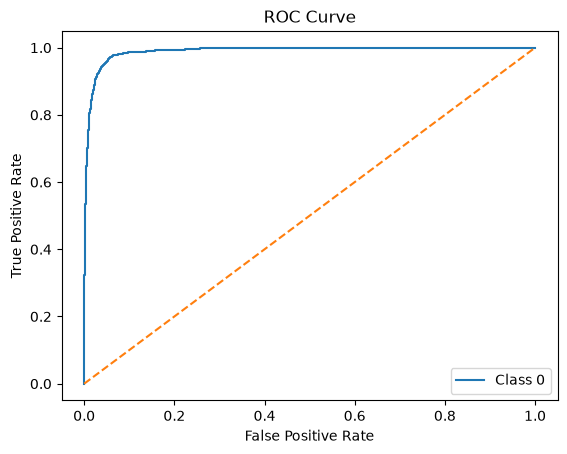

In [9]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Convert labels to one-hot format
y_test_bin = label_binarize(y_test, classes=range(10))

# Predict probabilities
y_score = model.predict(X_test)

# Calculate AUC Score
auc = roc_auc_score(
    y_test_bin,
    y_score,
    multi_class='ovr'
)

print("AUC Score:", auc)

# ROC Curve for Class 0
fpr, tpr, _ = roc_curve(
    y_test_bin[:, 0],
    y_score[:, 0]
)

plt.plot(fpr, tpr, label="Class 0")
plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()